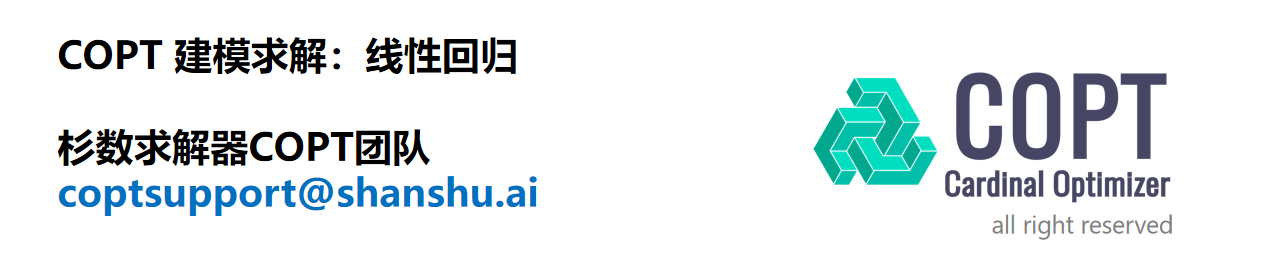

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

# 线性回归代码实现
## 使用COPT建模求解线性回归问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. 添加/导入模型**数据**

3. 创建**求解环境**和求解**模型**

4. **构建模型：依次添加三要素**
    - **决策变量**
    - **目标函数**
    - **约束条件**

5. **求解**

6. 查看和分析求解**结果**

### 导入COPT-Python接口库

In [1]:
from coptpy import *

### 数据

`point_data`是已知的19个数据点，其中`point_data`的键是点的标号，而键对应的值是点的数据$(x,y)$。

In [3]:
# point: [x, y]
point_data = {
    0: [0.0, 1.0],
    1: [0.5, 0.9],
    2: [1.0, 0.7],
    3: [1.5, 1.5],
    4: [1.9, 2.0],
    5: [2.5, 2.4],
    6: [3.0, 3.2],
    7: [3.5, 2.0],
    8: [4.0, 2.7],
    9: [4.5, 3.5],
    10: [5.0, 1.0],
    11: [5.5, 4.0],
    12: [6.0, 3.6],
    13: [6.6, 2.7],
    14: [7.0, 5.7],
    15: [7.6, 4.6],
    16: [8.5, 6.0],
    17: [9.0, 6.8],
    18: [10.0, 7.3],
}

我们希望将`point_data`中点的$x$和$y$分别取出，以方便绘图与之后的处理。

这里我们使用COPT的`multidict(data)`方法，`multidict(data)`能够将输入的Python字典对象拆分成多个字典对象返回。具体而言，`multidict(point_data)`会返回`point_data`的键、键与`x`对应的字典、键与`y`对应的字典。

In [5]:
points, x, y = multidict(point_data)

print('points:', points)
print('\nx:', x)
print('\ny:', y)

points: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

x: {0: 0.0, 1: 0.5, 2: 1.0, 3: 1.5, 4: 1.9, 5: 2.5, 6: 3.0, 7: 3.5, 8: 4.0, 9: 4.5, 10: 5.0, 11: 5.5, 12: 6.0, 13: 6.6, 14: 7.0, 15: 7.6, 16: 8.5, 17: 9.0, 18: 10.0}

y: {0: 1.0, 1: 0.9, 2: 0.7, 3: 1.5, 4: 2.0, 5: 2.4, 6: 3.2, 7: 2.0, 8: 2.7, 9: 3.5, 10: 1.0, 11: 4.0, 12: 3.6, 13: 2.7, 14: 5.7, 15: 4.6, 16: 6.0, 17: 6.8, 18: 7.3}


我们画图观察点$(x,y)$的分布，认为线性回归模型是较为合适的。

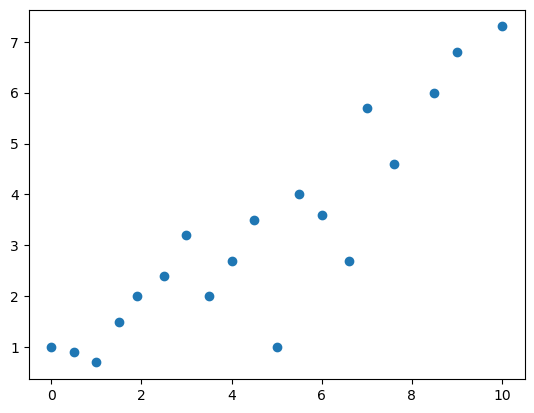

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(x.values(), y.values(), marker='o')
plt.show()

### 问题一

#### 创建模型

创建名为`linear_regression_q1`的模型`model_1`。

In [9]:
env = Envr()
model_1 = env.createModel("linear_regression_q1")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



#### 添加决策变量

添加决策变量$k,b,\{\epsilon_{i}\}_{i=1}^{n},\{t_{i}\}_{i=1}^{n}$。

这里要注意的是`Model.addVar()`和`Model.addVars()`默认参数`lb=0.0`和`ub=COPT.INFINITY`，但这里的$k,b,\{\epsilon_{i}\}_{i=1}^{n},\{t_{i}\}_{i=1}^{n}$都是无界的。

而对$i=1,...,n$，有
$$
\begin{cases}
\epsilon_{i} \leq t_{i} \\
\epsilon_{i} \geq -t_{i}
\end{cases}
\ \Rightarrow\ t_{i} \geq 0
$$
所以这里`t`也可使用默认的`lb=0.0`。

In [11]:
k = model_1.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="k")
b = model_1.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
e = model_1.addVars(points, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="e")
t = model_1.addVars(points, nameprefix="t")

#### 添加约束

使用`Model.addConstrs()`添加约束
$$
\begin{aligned}
& y_{i} = kx_{i} + b + \epsilon_{i}, &i = 1,...,n \\
& \epsilon_{i} \leq t_{i}, &i = 1,...,n \\
& \epsilon_{i} \geq -t_{i}, &i = 1,...,n
\end{aligned}
$$

In [13]:
model_1.addConstrs(k*x[i] + b + e[i] == y[i] for i in points)
model_1.addConstrs(e[i] <= t[i] for i in points)
model_1.addConstrs(e[i] >= -t[i] for i in points)

#### 设置目标函数并求解

目标函数为
$$
\min_{k,b\in\mathbb{R}}\ \sum_{i=1}^{n} t_{i}
$$
使用`tupledict.sum()`添加求和的目标函数。

In [15]:
model_1.setObjective(t.sum(), sense=COPT.MINIMIZE)
model_1.solve()

Model fingerprint: 969272f4

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an LP problem

The original problem has:
    57 rows, 40 columns and 132 non-zero elements
The presolved problem has:
    38 rows, 21 columns and 112 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [3e-01,2e+00]
    Range of rhs coefficients:       [1e+00,6e+00]
    Range of bound coefficients:     [0e+00,0e+00]
    Range of cost coefficients:      [5e-01,2e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    0.0000000000e+00           19           0       0.03s
Dual            21    1.1466557094e+01            0           0       0.03s
Postsolving
Dual            21    1.1466250000e+01            0           0 

#### 查看结果

回归结果为$y = 0.6375x + 0.5813$，我们画出了线性回归所得的直线。

y = 0.6375x + (0.5813)


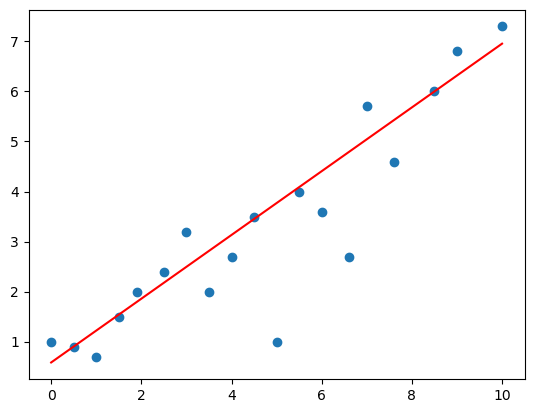

In [17]:
if model_1.status == COPT.OPTIMAL:
    print('y = {0:.4f}x + ({1:.4f})'.format(k.x, b.x))
    
    x1, x2 = min(x.values()), max(x.values())
    y1 = k.x*x1 + b.x
    y2 = k.x*x2 + b.x
    plt.scatter(x.values(), y.values(), marker='o')
    plt.plot([x1,x2], [y1,y2], color='r')
    plt.show()

### 问题二

#### 创建模型

创建名为`linear_regression_q2`的模型`model_2`。

In [19]:
model_2 = env.createModel("linear_regression_q2")

#### 添加决策变量

添加决策变量$k,b,\{\epsilon_{i}\}_{i=1}^{n},z$。

这里对$i=1,...,n$，有
$$
\begin{cases}
\epsilon_{i} \leq z \\
\epsilon_{i} \geq -z
\end{cases}
\ \Rightarrow\ z \geq 0
$$
所以这里`z`也可使用`Model.addVar()`默认的`lb=0.0`。

In [21]:
k = model_2.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="k")
b = model_2.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
e = model_2.addVars(points, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="e")
z = model_2.addVar(name="z")

#### 添加约束

使用`Model.addConstrs()`添加约束
$$
\begin{aligned}
& y_{i} = kx_{i} + b + \epsilon_{i}, &i = 1,...,n \\
& \epsilon_{i} \leq z, &i = 1,...,n \\
& \epsilon_{i} \geq -z, &i = 1,...,n
\end{aligned}
$$

In [23]:
model_2.addConstrs(k*x[i] + b + e[i] == y[i] for i in points)
model_2.addConstrs(z >= e[i] for i in points)
model_2.addConstrs(z >= -e[i] for i in points)

#### 设置目标函数并求解

目标函数为
$$
\min_{k,b\in\mathbb{R}}\ z
$$

In [25]:
model_2.setObjective(z, sense=COPT.MINIMIZE)
model_2.solve()

Model fingerprint: f4f32f6f

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an LP problem

The original problem has:
    57 rows, 22 columns and 132 non-zero elements
The presolved problem has:
    38 rows, 3 columns and 112 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [3e-01,3e+00]
    Range of rhs coefficients:       [1e+00,7e+00]
    Range of bound coefficients:     [0e+00,0e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    0.0000000000e+00           19           0       0.01s
Dual             5    1.7250231928e+00            0           0       0.01s
Postsolving
Dual             5    1.7250000000e+00            0           0  

#### 查看结果

回归结果为$y = 0.6250x - 0.4000$，我们画出了线性回归所得的直线。

y = 0.6250x + (-0.4000)


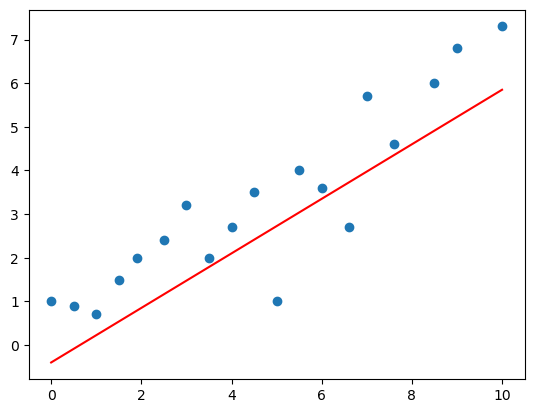

In [27]:
if model_2.status == COPT.OPTIMAL:
    print('y = {0:.4f}x + ({1:.4f})'.format(k.x, b.x))
    
    x1, x2 = min(x.values()), max(x.values())
    y1 = k.x*x1 + b.x
    y2 = k.x*x2 + b.x
    plt.scatter(x.values(), y.values(), marker='o')
    plt.plot([x1,x2], [y1,y2], color='r')
    plt.show()